In [ ]:
!pip install -q transformers accelerate pillow datasets

In [ ]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

# Load model
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Load dataset
dataset = load_dataset("anvo25/vlms-are-biased", split="main")

# 1. Exclude optical illusions
dataset = dataset.filter(lambda x: x['topic'] != 'Optical Illusion')

# 2. Add index for tracking
dataset = dataset.add_column("idx", list(range(len(dataset))))
torch.save(dataset["idx"], "qwen_indices.pt")

# 3. Sanity check distribution
topic_counts = Counter(dataset['topic'])
for topic, count in topic_counts.items():
    print(f"{topic}: {count}")

print(f"\nTotal: {len(dataset)}")

Filter:   0%|          | 0/2784 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1992 [00:00<?, ? examples/s]

Game Boards: 168
Patterned Grid: 336
Chess Pieces: 288
Logos: 414
Flags: 240
Animals: 546

Total: 1992


In [ ]:
def score_sequence(image, prompt, answer):
    """Score a candidate answer by computing its sequence logprob."""
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    }]
    prompt_text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    full_text = prompt_text + str(answer)

    # Tokenize prompt alone to find where the answer starts
    prompt_inputs = processor(text=[prompt_text], images=[image], return_tensors="pt")
    prompt_len = prompt_inputs["input_ids"].shape[1]

    # Tokenize full sequence (prompt + answer)
    inputs = processor(text=[full_text], images=[image], return_tensors="pt").to("cuda")
    inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)

    with torch.no_grad():
        outputs = model(**inputs)

    log_probs = torch.log_softmax(outputs.logits, dim=-1)

    # Logits at position i predict the token at position i+1
    answer_ids = inputs["input_ids"][0, prompt_len:]
    per_tok_lp, entropies = [], []
    for i, tok_id in enumerate(answer_ids):
        pos = prompt_len - 1 + i
        per_tok_lp.append(log_probs[0, pos, tok_id].item())
        d = log_probs[0, pos]
        entropies.append(-(d.exp() * d).sum().item())

    return {
        "seq_logprob": sum(per_tok_lp),
        "avg_logprob": sum(per_tok_lp) / len(per_tok_lp),
        "entropy_step1": entropies[0],
        "entropy_mean": sum(entropies) / len(entropies),
        "n_tokens": len(answer_ids),
    }


def analyze_sample(sample):
    gt = str(sample['ground_truth'])
    bias = str(sample['expected_bias'])

    gold = score_sequence(sample['image'], sample['prompt'], gt)
    biased = score_sequence(sample['image'], sample['prompt'], bias)

    return {
        "topic": sample['topic'],
        "question_type": sample['type_of_question'],
        "ground_truth": gt,
        "expected_bias": bias,

        # Gold scores
        "gold_seq_logprob": gold["seq_logprob"],
        "gold_avg_logprob": gold["avg_logprob"],
        "gold_entropy_step1": gold["entropy_step1"],
        "gold_entropy_mean": gold["entropy_mean"],
        "gold_n_tokens": gold["n_tokens"],

        # Bias scores
        "bias_seq_logprob": biased["seq_logprob"],
        "bias_avg_logprob": biased["avg_logprob"],
        "bias_entropy_step1": biased["entropy_step1"],
        "bias_n_tokens": biased["n_tokens"],

        # Margins
        "seq_margin": gold["seq_logprob"] - biased["seq_logprob"],
        "avg_margin": gold["avg_logprob"] - biased["avg_logprob"],

        # Useful flag for analysis
        "same_length": gold["n_tokens"] == biased["n_tokens"],
    }


def score_unconditional(answer):
    """
    Score answer against 'Answer:' with no image.
    Used to compute PMI = P(answer|image,prompt) - P(answer|'Answer:')
    """
    uncond_prompt = "Answer:"
    full_text = uncond_prompt + str(answer)

    prompt_ids = processor.tokenizer(
        uncond_prompt, return_tensors="pt", add_special_tokens=False
    )["input_ids"].to("cuda")

    full_ids = processor.tokenizer(
        full_text, return_tensors="pt", add_special_tokens=False
    )["input_ids"].to("cuda")

    prompt_len = prompt_ids.shape[1]

    with torch.no_grad():
        outputs = model(input_ids=full_ids)

    log_probs = torch.log_softmax(outputs.logits, dim=-1)
    answer_ids = full_ids[0, prompt_len:]

    per_tok_lp = []
    for i, tok_id in enumerate(answer_ids):
        pos = prompt_len - 1 + i
        per_tok_lp.append(log_probs[0, pos, tok_id].item())

    seq_lp = sum(per_tok_lp)
    n = len(per_tok_lp)
    return {
        "seq_logprob":  seq_lp,
        "avg_logprob":  seq_lp / n,
        "char_logprob": seq_lp / len(str(answer)),
        "n_tokens":     n
    }

In [ ]:
r = analyze_sample(dataset[0])
print(r)

NameError: name 'dataset' is not defined

In [ ]:
def run_batch(dataset, max_samples=None):
    results = []
    fails = 0
    data = dataset if max_samples is None else dataset.select(range(max_samples))

    for sample in tqdm(data):
        try:
            r = analyze_sample(sample)
            if r is not None:
                results.append(r)
        except Exception as e:
            fails += 1
            if fails <= 3:  # print first 3 errors only
                print(f"Failed at idx {sample.get('idx', '?')}: {e}")
            continue

    print(f"Total failures: {fails}")
    return results

results = run_batch(dataset)
print(f"Collected {len(results)}")

# Save as parquet file
df = pd.DataFrame(results)
df.to_parquet("qwen_seq_results_7b.parquet")

100%|██████████| 1992/1992 [1:07:30<00:00,  2.03s/it]

Total failures: 0
Collected 1992


# **Analysis**

In [ ]:
# Load the parquet file
df = pd.read_parquet("qwen_seq_results_7b.parquet")
print(f"Total samples: {len(df)}")
print(df.head())

Total samples: 1992
         topic question_type ground_truth expected_bias  gold_seq_logprob  \
0  Game Boards            Q1           10             9        -14.244141   
1  Game Boards            Q2           10             9        -13.303223   
2  Game Boards            Q1           10             9        -15.387695   
3  Game Boards            Q2           10             9        -14.187012   
4  Game Boards            Q1           10             9        -15.145996   

   gold_avg_logprob  gold_entropy_step1  gold_entropy_mean  gold_n_tokens  \
0         -7.122070            0.049225           0.809769              2   
1         -6.651611            0.182983           0.952332              2   
2         -7.693848            0.041168           0.863358              2   
3         -7.093506            0.157593           0.957703              2   
4         -7.572998            0.029083           0.968643              2   

   bias_seq_logprob  bias_avg_logprob  bias_entropy_st

In [ ]:
# Collect unique GT and bias values across the whole dataset
unique_values = set(df["ground_truth"].unique()) | set(df["expected_bias"].unique())
print(f"Running unconditional scoring for {len(unique_values)} unique values: "
      f"{sorted(unique_values)}")

uncond_scores = {}
for val in sorted(unique_values):
    uncond_scores[val] = score_unconditional(val)
    print(f"  {str(val):>4s}  avg_lp={uncond_scores[val]['avg_logprob']:.4f}  "
          f"n_tokens={uncond_scores[val]['n_tokens']}")

Running unconditional scoring for 25 unique values: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '31', '32', '4', '49', '5', '50', '51', '6', '7', '8', '9']
     1  avg_lp=-7.1562  n_tokens=1
    10  avg_lp=-4.6455  n_tokens=2
    11  avg_lp=-4.9268  n_tokens=2
    12  avg_lp=-4.7646  n_tokens=2
    13  avg_lp=-5.1045  n_tokens=2
    14  avg_lp=-5.0850  n_tokens=2
    15  avg_lp=-4.8506  n_tokens=2
    16  avg_lp=-5.0146  n_tokens=2
    17  avg_lp=-5.1670  n_tokens=2
    18  avg_lp=-5.0225  n_tokens=2
    19  avg_lp=-5.1982  n_tokens=2
     2  avg_lp=-8.3125  n_tokens=1
    20  avg_lp=-5.1641  n_tokens=2
     3  avg_lp=-8.4922  n_tokens=1
    31  avg_lp=-5.6660  n_tokens=2
    32  avg_lp=-5.6270  n_tokens=2
     4  avg_lp=-8.6016  n_tokens=1
    49  avg_lp=-6.0322  n_tokens=2
     5  avg_lp=-8.6094  n_tokens=1
    50  avg_lp=-5.3418  n_tokens=2
    51  avg_lp=-5.6777  n_tokens=2
     6  avg_lp=-8.8906  n_tokens=1
     7  avg_lp=-9.0234  n_tokens=1
 

In [ ]:
# Derive PMI columns from existing df -- no re-scoring of images needed
df["gold_uncond_avg_lp"]  = df["ground_truth"].map({k: v["avg_logprob"]  for k, v in uncond_scores.items()})
df["bias_uncond_avg_lp"]  = df["expected_bias"].map({k: v["avg_logprob"]  for k, v in uncond_scores.items()})
df["gold_uncond_char_lp"] = df["ground_truth"].map({k: v["char_logprob"] for k, v in uncond_scores.items()})
df["bias_uncond_char_lp"] = df["expected_bias"].map({k: v["char_logprob"] for k, v in uncond_scores.items()})

df["gold_pmi"]     = df["gold_avg_logprob"]  - df["gold_uncond_avg_lp"]
df["bias_pmi"]     = df["bias_avg_logprob"]  - df["bias_uncond_avg_lp"]
df["pmi_margin"]   = df["gold_pmi"]          - df["bias_pmi"]
df["prefers_gold_pmi"] = df["pmi_margin"]    > 0

# Also add char normalisation columns (derived from existing seq_logprob)
df["gold_char_logprob"] = df["gold_seq_logprob"] / df["ground_truth"].astype(str).str.len()
df["bias_char_logprob"] = df["bias_seq_logprob"] / df["expected_bias"].astype(str).str.len()
df["char_margin"]       = df["gold_char_logprob"] - df["bias_char_logprob"]

# Overwrite parquet with PMI columns included
df.to_parquet("qwen_seq_results_7b.parquet", index=False)
print("Parquet updated with PMI and char columns.")
print("New columns:", [c for c in df.columns if "pmi" in c or "char" in c or "uncond" in c])

Parquet updated with PMI and char columns.
New columns: ['gold_uncond_avg_lp', 'bias_uncond_avg_lp', 'gold_uncond_char_lp', 'bias_uncond_char_lp', 'gold_pmi', 'bias_pmi', 'pmi_margin', 'prefers_gold_pmi', 'gold_char_logprob', 'bias_char_logprob', 'char_margin']


In [ ]:
# Sign of avg_margin tells us preference (use avg_margin since it's length-safe)
df["prefers_gold"] = df["avg_margin"] > 0

print("Overall: model prefers gold answer in",
      f"{df['prefers_gold'].mean()*100:.1f}% of samples\n")

print("By topic:")
print(df.groupby("topic")["prefers_gold"].agg(["mean", "count"]).round(3))

print("\nMean avg_margin by topic (negative = bias wins):")
print(df.groupby("topic")["avg_margin"].mean().sort_values().round(3))

Overall: model prefers gold answer in 15.3% of samples

By topic:
                 mean  count
topic                       
Animals         0.011    546
Chess Pieces    0.000    288
Flags           0.438    240
Game Boards     0.298    168
Logos           0.239    414
Patterned Grid  0.131    336

Mean avg_margin by topic (negative = bias wins):
topic
Animals          -8.129
Chess Pieces     -4.008
Logos            -2.477
Game Boards      -1.567
Patterned Grid   -1.121
Flags            -0.026
Name: avg_margin, dtype: float64


In [ ]:
print("=== PMI vs avg_margin agreement ===")
agree = (df["prefers_gold_pmi"] == df["prefers_gold"]).mean()
print(f"Direction agreement: {agree*100:.1f}%")

print("\nprefers_gold rate by topic — avg_margin vs PMI:")
comp = df.groupby("topic").agg(
    avg_margin_pct  = ("prefers_gold",     lambda x: x.mean()*100),
    pmi_margin_pct  = ("prefers_gold_pmi", lambda x: x.mean()*100),
    n               = ("topic",            "count")
).round(1)
comp["delta"] = (comp["pmi_margin_pct"] - comp["avg_margin_pct"]).round(1)
print(comp)

flipped = df[df["prefers_gold"] != df["prefers_gold_pmi"]]
print(f"\nRows where PMI flips verdict: {len(flipped)} ({len(flipped)/len(df)*100:.1f}%)")

=== PMI vs avg_margin agreement ===
Direction agreement: 96.6%

prefers_gold rate by topic — avg_margin vs PMI:
                avg_margin_pct  pmi_margin_pct    n  delta
topic                                                     
Animals                    1.1             1.1  546    0.0
Chess Pieces               0.0             0.0  288    0.0
Flags                     43.8            45.4  240    1.6
Game Boards               29.8            17.9  168  -11.9
Logos                     23.9            27.8  414    3.9
Patterned Grid            13.1            12.5  336   -0.6

Rows where PMI flips verdict: 68 (3.4%)


In [ ]:
flipped = df[df["prefers_gold"] != df["prefers_gold_pmi"]]
print(flipped.groupby("topic")[["ground_truth", "expected_bias",
      "avg_margin", "pmi_margin"]].head(10))

     ground_truth expected_bias  avg_margin  pmi_margin
60             11            10   -0.132812    0.179688
61             11            10   -0.257812    0.054688
66             11            10   -0.054688    0.257812
67             11            10   -0.218750    0.093750
97              2             3    0.390625   -0.007812
98              2             3    0.046875   -0.351562
99              2             3    0.203125   -0.195312
104             2             3    0.312500   -0.085938
105             2             3    0.046875   -0.351562
108             2             3    0.203125   -0.195312
110             2             3    0.250000   -0.148438
111             2             3    0.156250   -0.242188
113             2             3    0.046875   -0.351562
114             2             3    0.203125   -0.195312
626            18            19   -0.125000    0.039062
632            18            19   -0.148438    0.015625
792             2             1   -0.796875    0

In [ ]:
# Entropy at the answer position (gold's first token)
print("Mean gold_entropy_step1 by topic and bias direction:")
print(df.groupby(["topic", "prefers_gold"])["gold_entropy_step1"].mean().round(3))

print("\nMean gold_entropy_mean by topic:")
print(df.groupby("topic")["gold_entropy_mean"].mean().sort_values().round(3))

# Correlation: does low entropy go with wrong answers?
from scipy.stats import pointbiserialr
corr, p = pointbiserialr(df["prefers_gold"], df["gold_entropy_step1"])
print(f"\nCorrelation entropy vs prefers_gold: r={corr:.3f}, p={p:.2e}")

Mean gold_entropy_step1 by topic and bias direction:
topic           prefers_gold
Animals         False           0.027
Chess Pieces    False           0.043
Flags           False           0.034
                True            0.034
Game Boards     False           0.025
                True            0.024
Logos           False           0.031
                True            0.046
Patterned Grid  False           0.031
                True            0.034
Name: gold_entropy_step1, dtype: float64

Mean gold_entropy_mean by topic:
topic
Animals           0.027
Logos             0.032
Patterned Grid    0.032
Flags             0.224
Game Boards       0.393
Chess Pieces      0.480
Name: gold_entropy_mean, dtype: float64

Correlation entropy vs prefers_gold: r=nan, p=nan


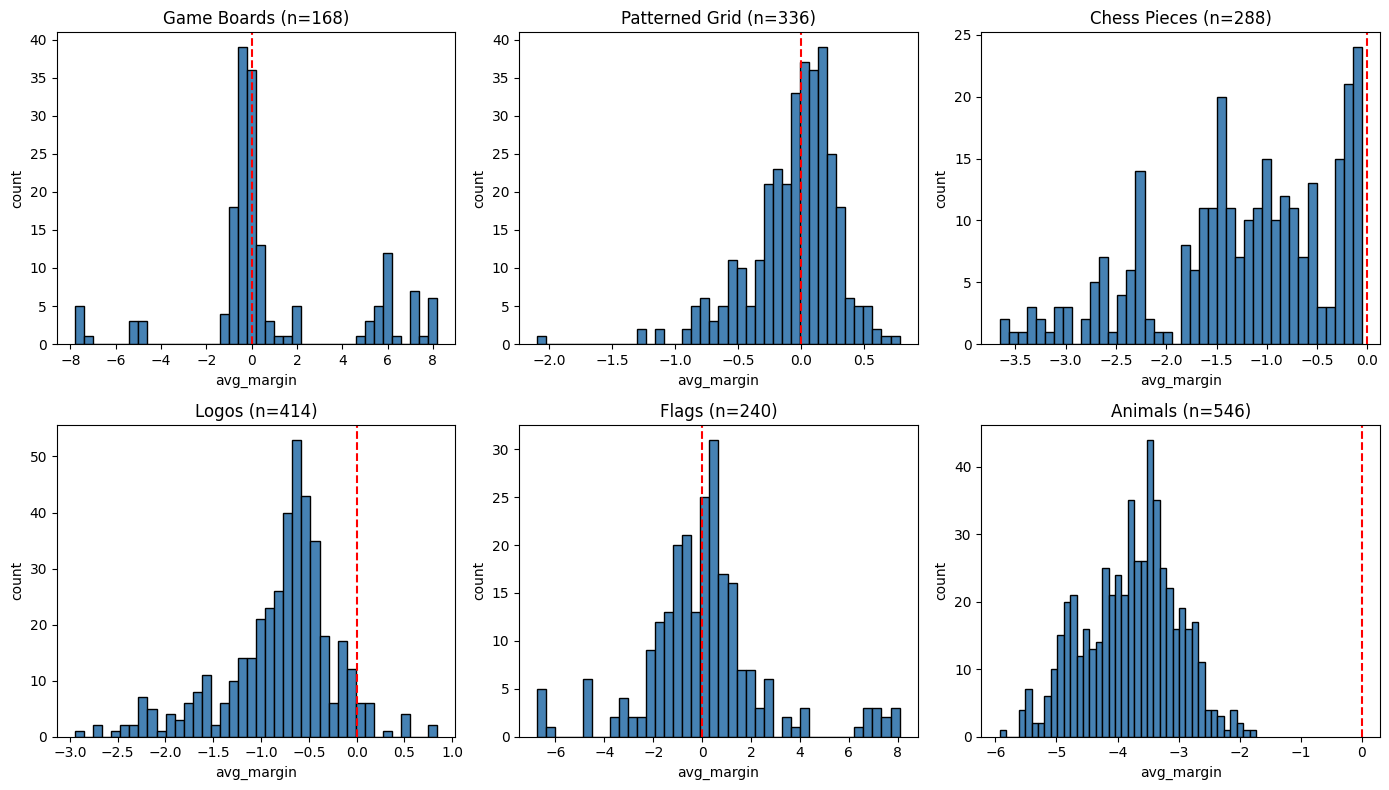

In [ ]:
# How extreme is the bias when it occurs?

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
topics = df["topic"].unique()

for ax, topic in zip(axes.flat, topics):
    sub = df[df["topic"] == topic]
    ax.hist(sub["avg_margin"], bins=40, color="steelblue", edgecolor="black")
    ax.axvline(0, color="red", linestyle="--", label="zero")
    ax.set_title(f"{topic} (n={len(sub)})")
    ax.set_xlabel("avg_margin")
    ax.set_ylabel("count")

plt.tight_layout()
plt.savefig("avg_margin_by_topic.png", dpi=120)
plt.show()

In [ ]:
# Does Q1/Q2/Q3 split the bimodality?
print(df.groupby(["topic", "question_type"])["avg_margin"].agg(["mean", "count"]).round(3))

                               mean  count
topic          question_type              
Animals        Q1            -3.716    273
               Q2            -3.844    273
Chess Pieces   Q1            -1.381    144
               Q2            -1.113    144
Flags          Q1             0.063    120
               Q2             0.050    120
Game Boards    Q1             0.773     84
               Q2             0.916     84
Logos          Q1            -0.858    206
               Q2            -0.736    206
Patterned Grid Q1            -0.102    168
               Q2            -0.016    168


In [ ]:
# Check original full dataset (before our filters) for Q3
raw = load_dataset("anvo25/vlms-are-biased", split="main")
print(Counter(raw["type_of_question"]))

Counter({'Q1': 1392, 'Q2': 1392})


In [ ]:
# What columns do we have? Check for logo names or similar
print(df.columns.tolist())
print()
# If there's a 'subject' or 'item' column, group by it
sub_logos = df[df["topic"] == "Logos"]
print(sub_logos.head(3))

['topic', 'question_type', 'ground_truth', 'expected_bias', 'gold_seq_logprob', 'gold_avg_logprob', 'gold_entropy_step1', 'gold_entropy_mean', 'gold_n_tokens', 'bias_seq_logprob', 'bias_avg_logprob', 'bias_entropy_step1', 'bias_n_tokens', 'seq_margin', 'avg_margin', 'same_length', 'prefers_gold']

     topic question_type ground_truth expected_bias  gold_seq_logprob  \
792  Logos            Q1            2             1        -11.101562   
793  Logos            Q1            2             1        -11.625000   
794  Logos            Q1            2             1        -12.234375   

     gold_avg_logprob  gold_entropy_step1  gold_entropy_mean  gold_n_tokens  \
792        -11.101562            0.047241           0.047241              1   
793        -11.625000            0.032623           0.032623              1   
794        -12.234375            0.024689           0.024689              1   

     bias_seq_logprob  bias_avg_logprob  bias_entropy_step1  bias_n_tokens  \
792        -1

In [ ]:
sub_logos = df[df["topic"] == "Logos"]
print("Logos: GT/bias pairs and avg_margin:")
print(sub_logos.groupby(["ground_truth", "expected_bias"])["avg_margin"]
      .agg(["mean", "count"]).round(2).sort_values("mean"))

sub_chess = df[df["topic"] == "Chess Pieces"]
print("\nChess: GT/bias pairs:")
print(sub_chess.groupby(["ground_truth", "expected_bias"])["avg_margin"]
      .agg(["mean", "count"]).round(2).sort_values("mean"))

Logos: GT/bias pairs and avg_margin:
                            mean  count
ground_truth expected_bias             
4            3             -1.03    162
2            1             -0.86     70
5            3             -0.72     90
             4             -0.40     90

Chess: GT/bias pairs:
                            mean  count
ground_truth expected_bias             
3            2             -2.65     54
17           16            -1.13      6
5            4             -1.09     84
31           32            -0.81    144


In [ ]:
df["relative_change"] = abs(df["ground_truth"].astype(float) - df["expected_bias"].astype(float)) / df["expected_bias"].astype(float)

from scipy.stats import pearsonr
r, p = pearsonr(df["relative_change"], df["avg_margin"])
print(f"Correlation between relative change size and avg_margin: r={r:.3f}, p={p:.2e}")

Correlation between relative change size and avg_margin: r=nan, p=nan


In [ ]:
df["relative_change"] = (
    abs(df["ground_truth"].astype(float) - df["expected_bias"].astype(float))
    / df["expected_bias"].astype(float)
)

print("Correlation between relative_change and avg_margin, by topic:\n")
for topic in df["topic"].unique():
    sub = df[df["topic"] == topic]
    if sub["relative_change"].nunique() > 1:  # need variation to correlate
        r, p = pearsonr(sub["relative_change"], sub["avg_margin"])
        print(f"  {topic:15s}  r={r:+.3f}  p={p:.3e}  (n={len(sub)})")
    else:
        print(f"  {topic:15s}  no variation in relative_change")

Correlation between relative_change and avg_margin, by topic:

  Game Boards      r=+0.150  p=5.283e-02  (n=168)
  Patterned Grid   r=+0.068  p=2.162e-01  (n=336)
  Chess Pieces     r=-0.723  p=7.155e-48  (n=288)
  Logos            r=+nan  p=nan  (n=414)
  Flags            r=+0.360  p=9.698e-09  (n=240)
  Animals          r=+0.414  p=5.091e-24  (n=546)


In [ ]:
# Look at the actual GT/bias pairs per topic to understand what relative_change captures
print("GT/bias pairs by topic with avg_margin and count:\n")
for topic in df["topic"].unique():
    sub = df[df["topic"] == topic]
    print(f"--- {topic} ---")
    print(sub.groupby(["ground_truth", "expected_bias"])["avg_margin"]
          .agg(["mean", "count"]).round(2))
    print()

GT/bias pairs by topic with avg_margin and count:

--- Game Boards ---
                            mean  count
ground_truth expected_bias             
10           9              6.46     36
11           10            -0.39     12
18           19            -0.33     12
20           19            -0.30     12
7            8             -0.55     24
8            9              0.35     36
9            10            -6.29     12
             8             -0.09     24

--- Patterned Grid ---
                            mean  count
ground_truth expected_bias             
2            3              0.13     54
3            4             -0.08    198
4            3             -0.44     18
5            4             -0.04     66

--- Chess Pieces ---
                            mean  count
ground_truth expected_bias             
17           16            -1.13      6
3            2             -2.65     54
31           32            -0.81    144
5            4             -1.09     84

--

In [ ]:
df["gt_minus_bias"] = df["ground_truth"].astype(float) - df["expected_bias"].astype(float)
df["direction"] = df["gt_minus_bias"].apply(lambda x: "added (GT>bias)" if x > 0 else "removed (GT<bias)")

print("Bias by direction of change:")
print(df.groupby("direction")["avg_margin"].agg(["mean", "count"]).round(3))

print("\nBy topic and direction:")
print(df.groupby(["topic", "direction"])["avg_margin"].agg(["mean", "count"]).round(3))

Bias by direction of change:
                    mean  count
direction                      
added (GT>bias)   -1.734   1390
removed (GT<bias) -0.342    600

By topic and direction:
                                   mean  count
topic          direction                      
Animals        added (GT>bias)   -3.780    546
Chess Pieces   added (GT>bias)   -1.679    144
               removed (GT<bias) -0.814    144
Flags          added (GT>bias)    0.100    120
               removed (GT<bias)  0.013    120
Game Boards    added (GT>bias)    2.645     84
               removed (GT<bias) -0.956     84
Logos          added (GT>bias)   -0.797    412
Patterned Grid added (GT>bias)   -0.123     84
               removed (GT<bias) -0.038    252


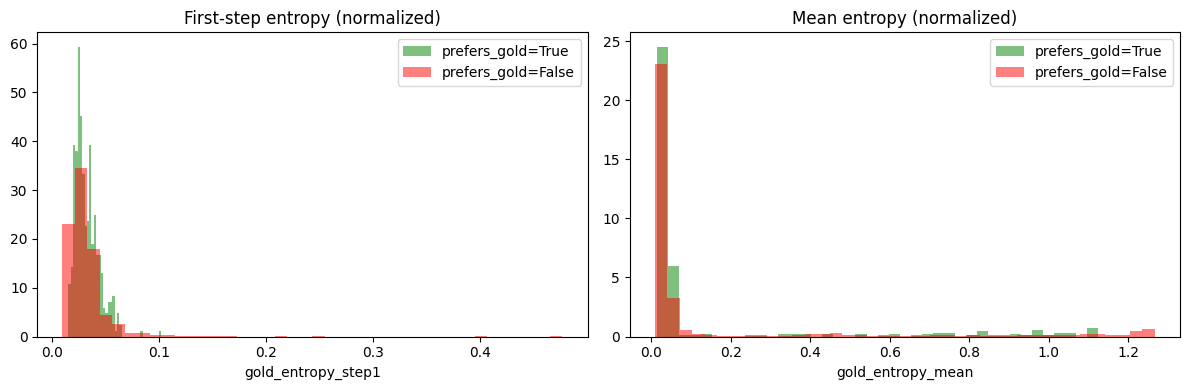

Mean entropy by gold token count and correctness:
gold_n_tokens  prefers_gold
1              False           0.032
               True            0.034
2              False           0.818
               True            0.770
Name: gold_entropy_mean, dtype: float64


In [ ]:
# Re-do but normalize histograms (density), and split by token length

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [(True, "green"), (False, "red")]:
    sub = df[df["prefers_gold"] == label]["gold_entropy_step1"]
    ax[0].hist(sub, bins=40, alpha=0.5, label=f"prefers_gold={label}",
               color=color, density=True)
ax[0].set_xlabel("gold_entropy_step1")
ax[0].set_title("First-step entropy (normalized)")
ax[0].legend()

for label, color in [(True, "green"), (False, "red")]:
    sub = df[df["prefers_gold"] == label]["gold_entropy_mean"]
    ax[1].hist(sub, bins=40, alpha=0.5, label=f"prefers_gold={label}",
               color=color, density=True)
ax[1].set_xlabel("gold_entropy_mean")
ax[1].set_title("Mean entropy (normalized)")
ax[1].legend()

plt.tight_layout()
plt.show()

# Confirm token-length confound on entropy_mean
print("Mean entropy by gold token count and correctness:")
print(df.groupby(["gold_n_tokens", "prefers_gold"])["gold_entropy_mean"].mean().round(3))

In [ ]:
# Where do the two margin metrics disagree on direction?
df["seq_prefers_gold"] = df["seq_margin"] > 0
df["avg_prefers_gold"] = df["avg_margin"] > 0

disagree = df[df["seq_prefers_gold"] != df["avg_prefers_gold"]]
print(f"Disagree on direction: {len(disagree)} samples ({len(disagree)/len(df)*100:.1f}%)")
print("\nThese should mostly be mixed-length cases (where length confounds seq_margin):")
print(disagree["same_length"].value_counts())

Disagree on direction: 23 samples (1.2%)

These should mostly be mixed-length cases (where length confounds seq_margin):
same_length
False    23
Name: count, dtype: int64
